# FLF–BiLSTM (Configurable) – EURUSD H4

Konversi dari `FLF_BiLSTM_Forex_configurable.py` ke bentuk notebook.

**Fitur**:
- BiLSTM + Forex Loss Function (FLF)
- Autodeteksi kolom OHLC (open|high|low|close)
- Parameter dapat dikonfigurasi di sel Konfigurasi
- Output CSV + plot loss & overlay prediksi

> Pastikan `tensorflow`, `numpy`, `pandas`, `matplotlib` sudah terpasang.

In [1]:
# === 0) Konfigurasi (ubah sesuai kebutuhan) ===
import os

EURUSD_TAB_PATH = os.environ.get("EURUSD_TAB_PATH", "D:/CodingProgramming/RisetEU/risetBiLstmPy/EURUSD_H4_25Oct17.csv")  # path file input
SEP              = os.environ.get("SEP", "\t")                                   # delimiter ("\t", ",", ";")
WINDOW           = int(os.environ.get("WINDOW", 1))                               # panjang sequence
SPLIT_RATIO      = float(os.environ.get("SPL_RATIO", os.environ.get("SPLIT_RATIO", 0.60)))

EPOCHS           = int(os.environ.get("EPOCHS", 50))
BATCH            = int(os.environ.get("BATCH", 72))
SEED             = int(os.environ.get("SEED", 42))

UNITS                = int(os.environ.get("UNITS", 200))
LSTM_ACTIVATION      = os.environ.get("LSTM_ACTIVATION", "tanh")
RECURRENT_ACTIVATION = os.environ.get("RECURRENT_ACTIVATION", "sigmoid")
OUTPUT_ACTIVATION    = os.environ.get("OUTPUT_ACTIVATION", "")  # kosong = linear

LR             = float(os.environ.get("LR", 1e-5))
BETA_1         = float(os.environ.get("BETA_1", 0.09))
BETA_2         = float(os.environ.get("BETA_2", 0.0999))
SCHEDULE_DECAY = float(os.environ.get("SCHEDULE_DECAY", 4e-4))

LAMBDA = float(os.environ.get("LAMBDA", 0.9))  # FLF λ
SIGMA  = float(os.environ.get("SIGMA", 0.1))  # FLF σ

OUT_PATH = os.environ.get("OUT_PATH", "FLF_BiLSTM_predictions.csv")

print("CONFIG:")
for k in [
    'EURUSD_TAB_PATH','SEP','WINDOW','SPLIT_RATIO','EPOCHS','BATCH','SEED',
    'UNITS','LSTM_ACTIVATION','RECURRENT_ACTIVATION','OUTPUT_ACTIVATION',
    'LR','BETA_1','BETA_2','SCHEDULE_DECAY','LAMBDA','SIGMA','OUT_PATH']:
    print(f"  {k} = {globals()[k]}")


CONFIG:
  EURUSD_TAB_PATH = D:/CodingProgramming/RisetEU/risetBiLstmPy/EURUSD_H4_25Oct17.csv
  SEP = 	
  WINDOW = 1
  SPLIT_RATIO = 0.6
  EPOCHS = 50
  BATCH = 72
  SEED = 42
  UNITS = 200
  LSTM_ACTIVATION = tanh
  RECURRENT_ACTIVATION = sigmoid
  OUTPUT_ACTIVATION = 
  LR = 1e-05
  BETA_1 = 0.09
  BETA_2 = 0.0999
  SCHEDULE_DECAY = 0.0004
  LAMBDA = 0.9
  SIGMA = 0.1
  OUT_PATH = FLF_BiLSTM_predictions.csv


In [2]:
# === 1) Import library ===
import time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Activation, InputLayer
from tensorflow.keras.optimizers import Nadam

random.seed(SEED)
np.random.seed(SEED)
try:
    tf.random.set_seed(SEED)
except Exception:
    pass


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

In [3]:
# === 2) Load data (tab/CSV) & deteksi kolom OHLC ===
def load_tab_data(path, sep):
    try:
        return pd.read_csv(path, sep=sep, engine="python")
    except Exception:
        df = pd.read_csv(path, engine="python")
        if df.shape[1] == 1:
            col = df.columns[0]
            df = df[col].str.split(sep, expand=True)
        return df

def find_ohlc(df: pd.DataFrame):
    cols = [str(c).strip().lower() for c in df.columns]
    df.columns = cols
    def pick_first(x): return x[0] if len(x)>0 else None
    open_col  = pick_first([c for c in cols if "open" in c or c == "o"])
    high_col  = pick_first([c for c in cols if "high" in c or c == "h"])
    low_col   = pick_first([c for c in cols if "low"  in c or c == "l"])
    close_col = pick_first([c for c in cols if "close" in c or c == "c"])
    if None in (open_col, high_col, low_col, close_col):
        numeric_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
        if len(numeric_cols) >= 4:
            open_col, high_col, low_col, close_col = numeric_cols[:4]
    assert all([open_col, high_col, low_col, close_col]), f"Missing OHLC columns in {df.columns.tolist()}"
    out = df[[open_col, high_col, low_col, close_col]].copy()
    out.columns = ["open","high","low","close"]
    out = out.dropna().reset_index(drop=True)
    return out

df_raw = load_tab_data(EURUSD_TAB_PATH, SEP)
ohlc = find_ohlc(df_raw)
ohlc.head()


,open,high,low,close
0,1.20088,1.20223,1.20007,1.20146
1,1.20152,1.20245,1.20069,1.20245
2,1.20246,1.20707,1.20227,1.20705
3,1.20705,1.20812,1.20562,1.20574
4,1.20572,1.20591,1.20261,1.20447


In [4]:
# === 3) Supervised windowing ===
def make_dataset(ohlc: pd.DataFrame, window: int):
    vals = ohlc[["open","high","low","close"]].values.astype("float32")
    X_list, y_list = [], []
    for i in range(len(vals)-window):
        X_list.append(vals[i:i+window, :])
        y_list.append(vals[i+window, :])
    return np.array(X_list), np.array(y_list)

X, y = make_dataset(ohlc, WINDOW)
split_idx = int(SPLIT_RATIO * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
len(X_train), len(X_test)


(7276, 4851)

In [5]:
# === 4) FLF Loss ===
def flf_loss(y_true, y_pred):
    y_o, y_h, y_l, y_c = y_true[...,0], y_true[...,1], y_true[...,2], y_true[...,3]
    ypo, yph, ypl, ypc = y_pred[...,0], y_pred[...,1], y_pred[...,2], y_pred[...,3]
    alpha_o = LAMBDA * (y_o - ypo)
    alpha_h = LAMBDA * (y_h - yph)
    alpha_l = LAMBDA * (y_l - ypl)
    alpha_c = LAMBDA * (y_c - ypc)
    avg_true_hl = (y_h + y_l) / 2.0
    avg_pred_hl = (yph + ypl) / 2.0
    beta  = SIGMA * (avg_true_hl - avg_pred_hl)
    avg_true_oc = (y_o + y_c) / 2.0
    avg_pred_oc = (ypo + ypc) / 2.0
    gamma = SIGMA * (avg_true_oc - avg_pred_oc)
    comp_o = alpha_o - gamma
    comp_h = alpha_h - beta
    comp_l = alpha_l - beta
    comp_c = alpha_c - gamma
    loss_vec = (comp_o**2 + comp_h**2 + comp_l**2 + comp_c**2) / 4.0
    return K.mean(loss_vec, axis=-1)


In [6]:
# === 5) Build BiLSTM model ===
from tensorflow.keras.layers import InputLayer

def build_bilstm_model(units=200, lstm_activation="tanh", recurrent_activation="sigmoid",
                       output_activation=None, window=1):
    model = Sequential()
    model.add(InputLayer(input_shape=(window, 4)))
    model.add(
        Bidirectional(
            LSTM(units=units,
                 activation=lstm_activation,
                 recurrent_activation=recurrent_activation,
                 return_sequences=False)
        )
    )
    model.add(Dense(4))
    if output_activation:
        model.add(Activation(output_activation))
    return model

model = build_bilstm_model(
    units=UNITS,
    lstm_activation=LSTM_ACTIVATION,
    recurrent_activation=RECURRENT_ACTIVATION,
    output_activation=(OUTPUT_ACTIVATION if OUTPUT_ACTIVATION.strip() else None),
    window=WINDOW
)
opt = Nadam(learning_rate=LR, beta_1=BETA_1, beta_2=BETA_2, schedule_decay=SCHEDULE_DECAY)
model.compile(optimizer=opt, loss=flf_loss)
model.summary()


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


ValueError: Argument(s) not recognized: {'schedule_decay': 0.0004}

In [ ]:
# === 6) Train ===
t0 = time.time()
hist = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                 epochs=EPOCHS, batch_size=BATCH, verbose=1)
print("Train time: %.2fs" % (time.time()-t0))


Train on 7276 samples, validate on 4851 samples
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Epoch 1/50
7276/7276 [==============================] - 2s 259us/sample - loss: 0.7807 - val_loss: 0.6828
Epoch 2/50
7276/7276 [==============================] - 1s 114us/sample - loss: 0.7414 - val_loss: 0.6477
Epoch 3/50
7276/7276 [==============================] - 1s 104us/sample - loss: 0.7030 - val_loss: 0.6133
Epoch 4/50
7276/7276 [==============================] - 1s 97us/sample - loss: 0.6652 - val_loss: 0.5795
Epoch 5/50
7276/7276 [==============================] - 1s 106us/sample - loss: 0.6281 - val_loss: 0.5461
Epoch 6/50
7276/7276 [==============================] - 1s 113us/sample - loss: 0.5914 - val_loss: 0.5132
Epoch 7/50
7276/7276 [==============================] - 1s 105us/sample - loss: 0.5552 - val_loss: 0.4807
Epoch 8/50
7276/7276 [==============================] - 1s 106us/sample - loss: 0.5194 - val_loss: 0.4486
Epoch 9/50


In [ ]:
# === 7) Evaluate & Save ===
y_pred = model.predict(X_test, verbose=0)

def mae(a,b):
    return float(np.mean(np.abs(a-b)))

metrics = {
    "MAE_open":  mae(y_test[:,0], y_pred[:,0]),
    "MAE_high":  mae(y_test[:,1], y_pred[:,1]),
    "MAE_low":   mae(y_test[:,2], y_pred[:,2]),
    "MAE_close": mae(y_test[:,3], y_pred[:,3])
}
metrics

pred_df = pd.DataFrame(y_pred, columns=["pred_open","pred_high","pred_low","pred_close"])
true_df = pd.DataFrame(y_test, columns=["true_open","true_high","true_low","true_close"])
out_df  = pd.concat([true_df, pred_df], axis=1)
out_df.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)


Saved: FLF_BiLSTM_predictions.csv


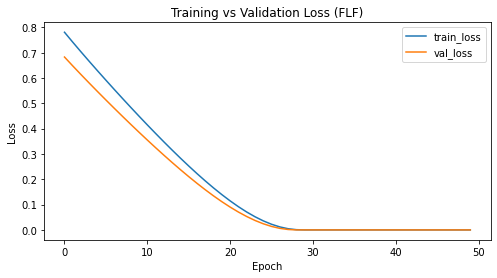

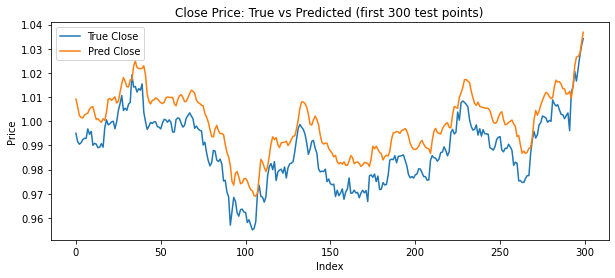

In [ ]:
# === 8) Plots ===
plt.figure(figsize=(8,4))
plt.plot(hist.history.get("loss", []), label="train_loss")
if "val_loss" in hist.history:
    plt.plot(hist.history["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss (FLF)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(); plt.show()

N_SHOW = min(300, len(y_pred))
plt.figure(figsize=(10,4))
plt.plot(true_df["true_close"].values[:N_SHOW], label="True Close")
plt.plot(pred_df["pred_close"].values[:N_SHOW], label="Pred Close")
plt.title(f"Close Price: True vs Predicted (first {N_SHOW} test points)")
plt.xlabel("Index"); plt.ylabel("Price"); plt.legend(); plt.show()
